In [1]:
import sys, os
from pathlib import Path

project_root = Path("Controlled_EDMD.ipynb").resolve().parent.parent
package_root = project_root /"KRTB_pyKoopman_EDMD"
sys.path.insert(0, str(package_root))

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ASR import custom_obs
import pykoopman as pk
from pykoopman import observables, regression
from KRTB_pyKoopman import KoopmanModelTrainer, KoopmanAnalysis, integralRK4
from controller import KoopmanMPC
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Generate training Data

In [ ]:
def random_accel(a_min=-3.0, a_max=2.0):
    return np.random.uniform(a_min, a_max)


def steering_multisine(t, amps=(0.25, 0.12), freqs=(0.2, 0.5)):
    delta = 0.0
    for A, f in zip(amps, freqs):
        delta += A * np.sin(2*np.pi*f*t + 2*np.pi*np.random.rand())
    return np.clip(delta, -0.4, 0.4)

## Generate a path

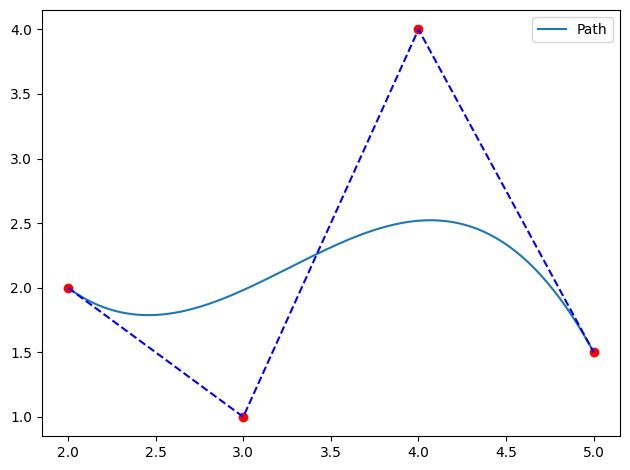

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import binom

def Bernstein(n, k):
    """Bernstein polynomial."""
    coeff = binom(n, k)
    def _bpoly(x):
        return coeff * x ** k * (1 - x) ** (n - k)

    return _bpoly

def Bezier(points, num=200):
    """Build Bézier curve from points."""
    N = points.shape[0]
    t = np.linspace(0, 1, num=num)
    curve = np.zeros((num, 2))
    for i in range(N):
        curve += np.outer(Bernstein(N - 1, i)(t), points[i, :])
    return curve
    
xp = np.array([2,3,4,5])
yp = np.array([2,1,4,1.5])
points = np.vstack([xp, yp]).T
pp = Bezier(points) # path points

plt.plot(pp[:, 0], pp[:, 1], label="Path")
plt.plot(xp,yp,"ro")
plt.plot(xp,yp,"b--")
plt.legend()

plt.tight_layout()
plt.show()

### create an instance of the path class

In [29]:
class Path:
    def __init__(self, waypoints):
        self.x, self.y = waypoints[:, 0], waypoints[:, 1]
        
        dx = np.diff(self.x)
        dy = np.diff(self.y)
        ds = np.sqrt(dx**2 + dy**2)

        self.s = np.cumsum(ds) # path parameterized by arc lenght s
        self.s -= self.s[0]
        self.length = self.s[-1]
        
        self.psi = np.arctan2(dy, dy) # heading angle along P(s)

    def evaluate(self, s_query):
        """This function interpolates between waypoints to find segment i such that 
        s[i] <= s < s[i+1]. Then it interpolate position and heading angle."""
        s_query = np.clip(s_query, 0, self.length)

        i = np.searchsorted(self.s, s_query)
        i = np.clip(i, 0, len(self.s)-2)

        s0, s1 = self.s[i], self.s[i+1]
        t = (s_query - s0) / (s1 - s0 + 1e-9)

        x = (1 - t) * self.x[i] + t * self.x[i+1]
        y = (1 - t) * self.y[i] + t * self.y[i+1]
        psi = self.psi[i]

        return x, y , psi

    def closest_s(self, x, y):
        min_dist = np.inf
        best_s = 0.0
    
        for i in range(len(self.x) - 2):
            p0 = np.array([self.x[i], self.y[i]])
            p1 = np.array([self.x[i+1], self.y[i+1]])
            d = p1 - p0
    
            if np.linalg.norm(d) < 1e-6:
                continue
    
            t = np.dot([x, y] - p0, d) / np.dot(d, d)
            t = np.clip(t, 0.0, 1.0)
    
            proj = p0 + t * d
            dist = np.linalg.norm([x, y] - proj)
    
            if dist < min_dist:
                min_dist = dist
                best_s = self.s[i] + t * (self.s[i+1] - self.s[i])

        return best_s

## EDMD Model

### Configuratoin

In [30]:
curdir = os.path.dirname("Controlled_EDMD.ipynb")
config_path = os.path.join(curdir, "config", "benchmark_ASR_forward.json")
stream = print

### Access simulated trajectory and EDMDc model

In [31]:
kmt = KoopmanModelTrainer(config_path, curdir, save_model=True, save_sim_data=True, stream=stream)
use_saved_data = True
if use_saved_data:
    states, controls, t_vec = kmt.loadSimTrajectories(control=True)
    pk_model = kmt.loadPyKoopmanModel()
else:
    states, controls, t_vec = kmt.simTrajWithControl(seed=4)
    
    reg = regression.EDMDc()
    obs = custom_obs
    pk_model = kmt.trainPyKoopmanModel(states, controls=controls, regressor=reg, observables=obs)

Simulated trajectories loaded from: sim_trajectories/benchmark_ASR_forward.npz
 Num. simulated trajectories: 10000
Simulation time span (sec): 4.950 [0.000, 4.950]
Trained model loaded from: models/benchmark_ASR_forward.pkl


## RUN KMPC

In [32]:
# n = 10
# traj = states[n]
# u = controls[n]
# print(traj[0, :])
# print
# plt.plot(traj[:, 0], traj[:, 1], '--r', label="True")

# plt.show()

In [33]:
A = pk_model.A
B = pk_model.B
nx = pk_model.C.shape[0]

Ctrb = np.hstack([B, A@B, A@A@B])
rank = np.linalg.matrix_rank(Ctrb)
print(f"rank: {rank}, nx: {nx}")

rank: 6, nx: 4


In [34]:
Q = np.diag([20, 20, 20, 2])
R = np.diag([0.1, 0.1])
Np = 12
kmpc = KoopmanMPC(pk_model, R, Q, u_min=np.array([-0.5, -np.pi/6]), 
                  u_max=np.array([0.5, np.pi/6]), n_horizon=Np)

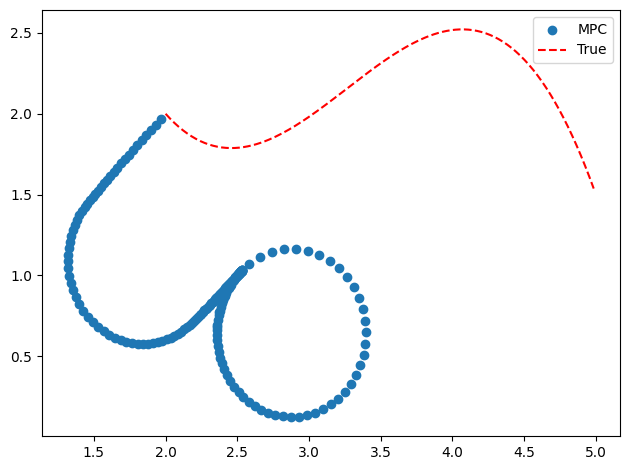

In [49]:
def build_reference(traj, i, Np):
    T = traj.shape[0]
    # Select reference window. Clamp if i+Np exceeds T-1
    end = min(i + Np, T)
    window = traj[i:end]

    # If the window is shorter, repeat the last state
    if window.shape[0] < Np:
        last = window[-1]
        repeat_count = Np - window.shape[0]
        repeat_block = np.tile(last, (repeat_count, 1))
        window = np.vstack((window, repeat_block))

    # Return shape (nx, Np)
    return window.T

traj = np.vstack([path.x[:-1], path.y[:-1], path.psi, np.ones(path.psi.shape)]).T


n_steps = traj.shape[0]
dt = 0.05
pos = np.zeros((n_steps, 2))

x = traj[0, :]
for i in range(n_steps):
    x_ref = build_reference(traj, i, kmpc.Np)
    u = kmpc.run(x, x_ref)
    x = integralRK4(kmt.system.ff, x.reshape(1, -1), u, dt).flatten()
    pos[i, :] = x[:2]

plt.scatter(pos[:, 0], pos[:, 1], label="MPC")
plt.plot(traj[:, 0], traj[:, 1], '--r', label="True")
plt.legend()
plt.tight_layout()
plt.show()

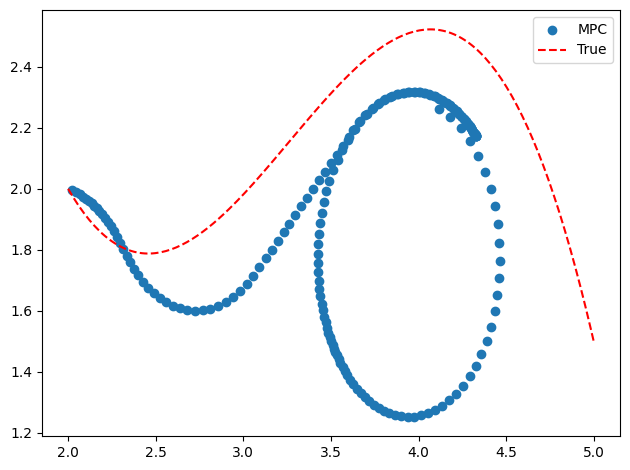

In [36]:
# v_ref = 1
# dt = 0.05
# path = Path(pp)

# n_steps = len(path.x)
# pos = np.zeros((n_steps, 2))

# x = np.array([2, 2, -0.2, 0.5])
# for i in range(n_steps):
#     s0 = path.closest_s(x[0], x[1])
#     x_ref = np.zeros((4, Np))
#     for k in range(Np):
#         s_k = s0 + k * v_ref * dt
#         x_r, y_r, psi_r = path.evaluate(s_k)
#         x_ref[:, k] = [x_r, y_r, psi_r, v_ref]
        
#     u = kmpc.run(x, x_ref)
#     x = integralRK4(kmt.system.ff, x.reshape(1, -1), u, dt).flatten()
#     pos[i, :] = x[:2]

# plt.scatter(pos[:, 0], pos[:, 1], label="MPC")
# plt.plot(path.x, path.y, '--r', label="True")
# plt.legend()

# plt.tight_layout()
# plt.show()